<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Atividade_ML_Fuzzy_C_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scikit-fuzzy --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 23.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fz
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = [15, 10]

In [4]:
url = 'http://github.com/higoramario/univesp-com410-aprendizado-de-maquinas/raw/main/social-network-ads.csv'
compras = pd.read_csv(url, sep=',')
compras.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


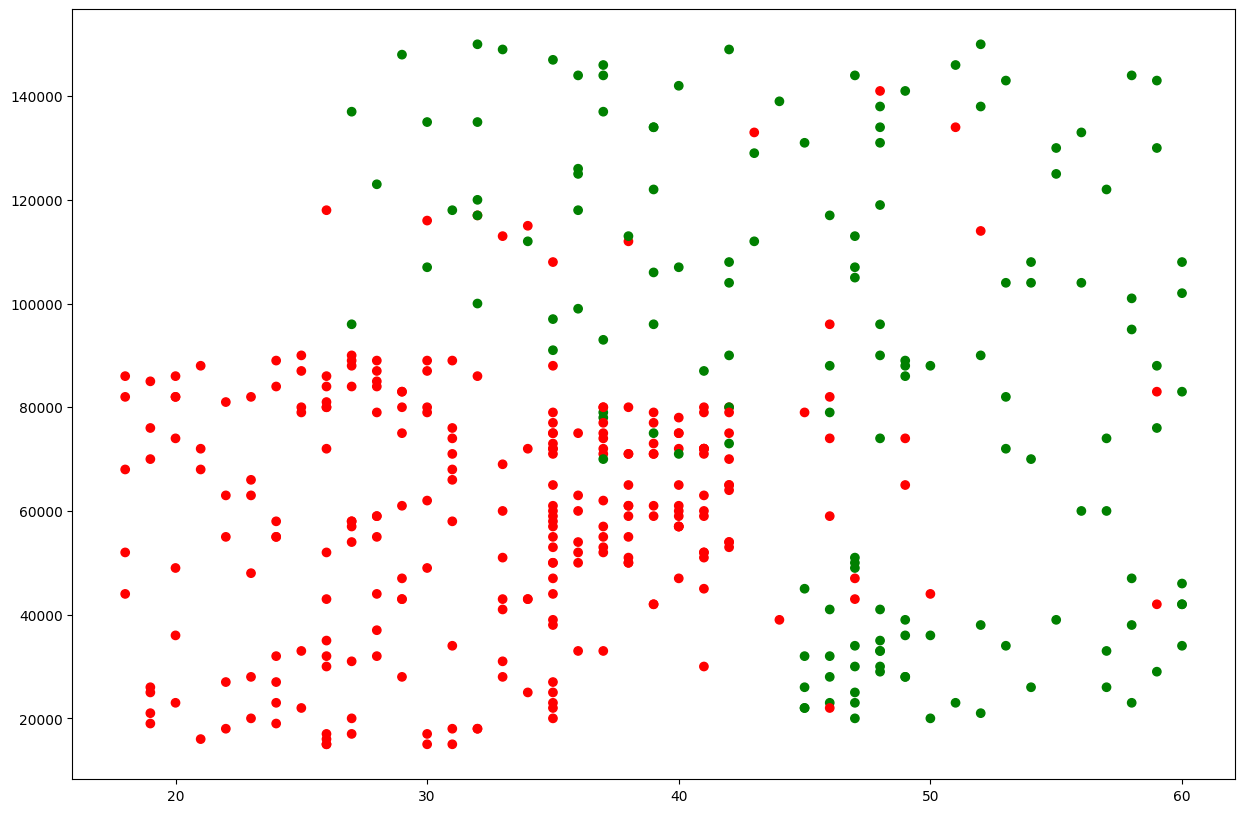

In [5]:
fig, ax = plt.subplots()
colors = {0: 'red', 1: 'green'}
ax.scatter(compras['Age'], compras['EstimatedSalary'], c=compras['Purchased'].map(colors))
plt.show()

In [6]:
compras_atributos = compras[['Age', 'EstimatedSalary']]
compras_classes = compras['Purchased']

In [8]:
scaler = StandardScaler()
compras_atributos = scaler.fit_transform(compras_atributos)

In [9]:
agrupamento = fz.cmeans(data=compras_atributos.T, c=2, m=2, error=0.005, maxiter=1000)

In [10]:
grau_pertinencia = agrupamento[1]

In [11]:
grau_pertinencia.shape

(2, 400)

In [12]:
grau_pertinencia[0][0]

np.float64(0.20624625645736525)

In [13]:
grau_pertinencia[1][0]

np.float64(0.7937537435426347)

In [14]:
clusters = grau_pertinencia.argmax(axis=0)

In [15]:
clusters

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,

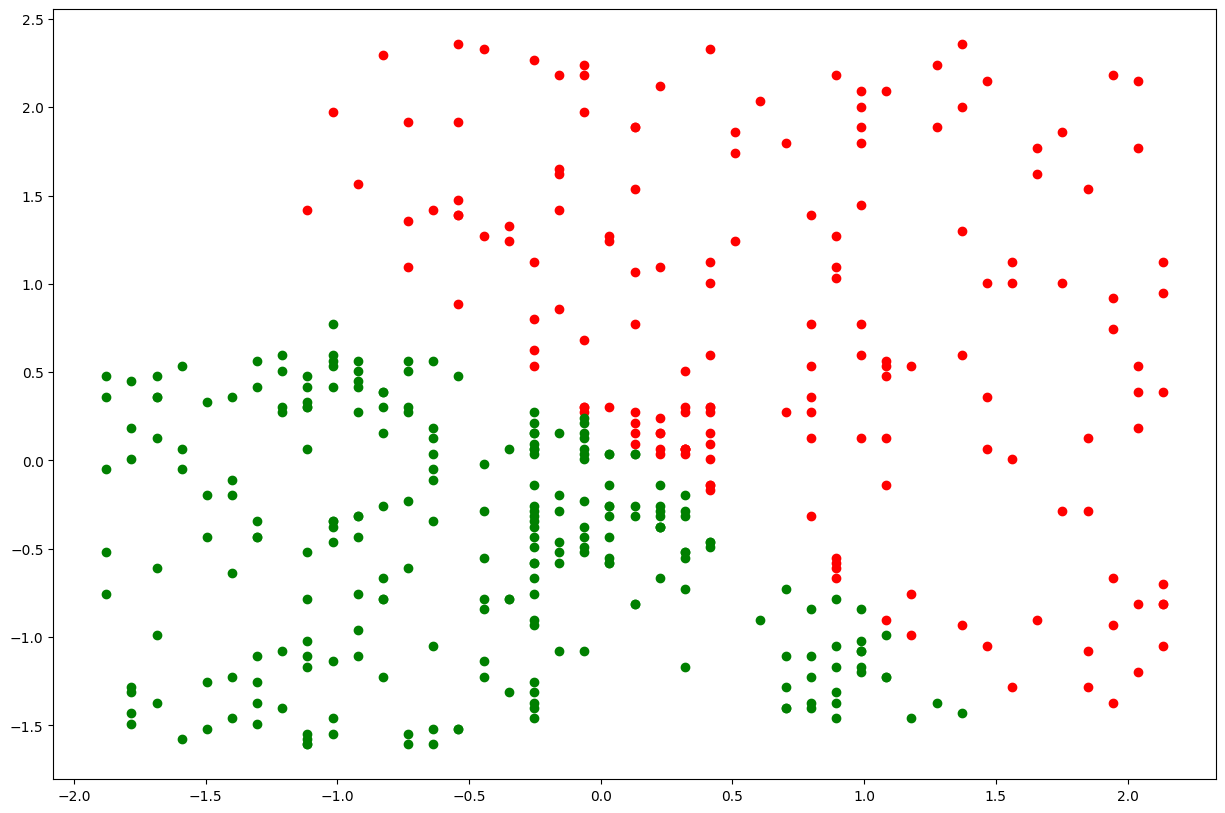

In [16]:
plt.scatter(compras_atributos[clusters == 0,0],
            compras_atributos[clusters == 0,1], c = 'red')
plt.scatter(compras_atributos[clusters == 1,0],
            compras_atributos[clusters == 1,1], c = 'green')
plt.show()

In [17]:
acuracia = accuracy_score(compras_classes.array, clusters)
print('Acurácia de classificação: {}'.format(round(acuracia,3)*100)+'%')

Acurácia de classificação: 19.0%


In [18]:
fuzzy = np.amax(grau_pertinencia, axis=0)

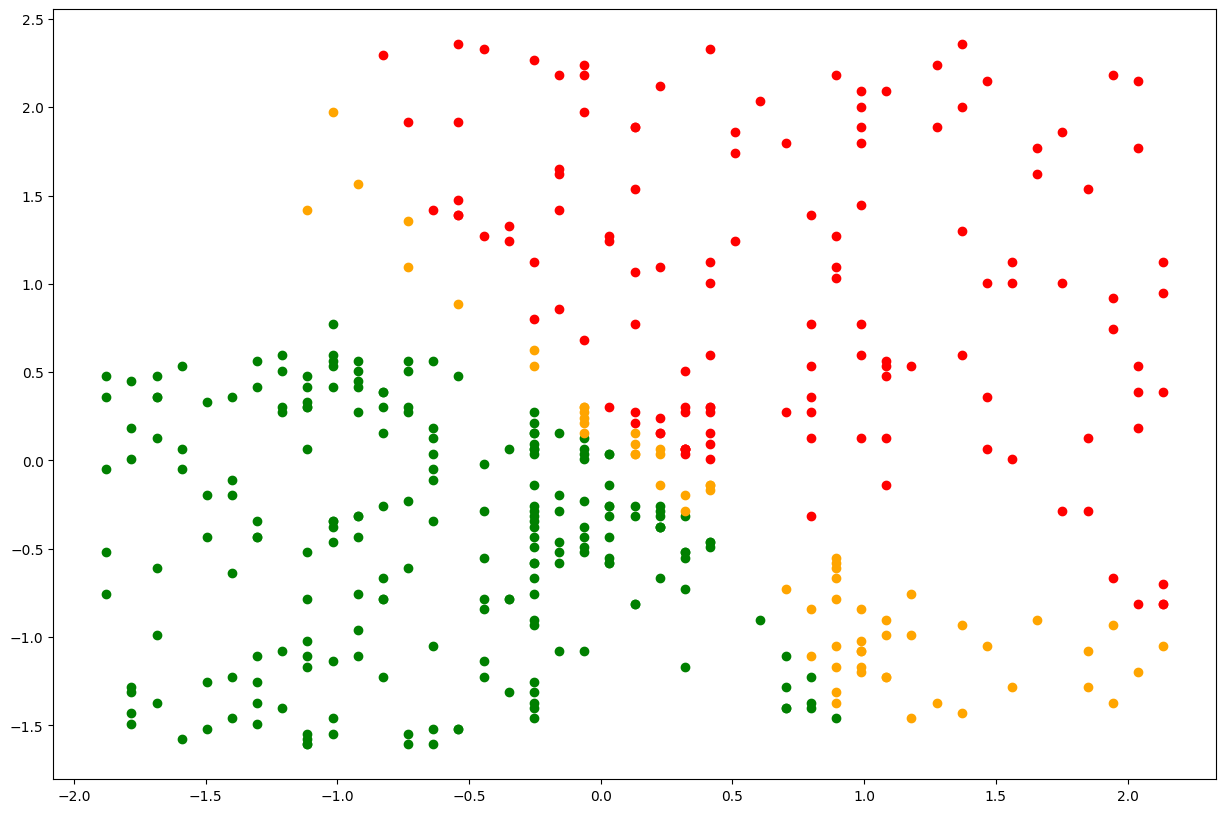

In [19]:
cores = ['red', 'green', 'orange']
corte = 0.6

for i, classe in enumerate(clusters):
  if fuzzy[i] >= corte:
    plt.scatter(compras_atributos[i,0], compras_atributos[i,1], c=cores[classe])
  else:
    plt.scatter(compras_atributos[i,0], compras_atributos[i,1], color=cores[len(cores)-1])

plt.show()